#### **Import libraries; read/filter files; define functions**

In [1]:
# import things
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as skm
import scipy.stats as st

Read and filter files

In [2]:
# Read long format PM file; filter
read_pm = pd.read_parquet('data/pm_long.pq')
read_pm['timestamp']=pd.to_datetime((read_pm['date'].astype(str) + ' ' + read_pm['time'].astype(str)),utc=True).dt.tz_convert('US/Eastern')
read_pm['time_naive']=read_pm['timestamp'].dt.strftime('%I:%M')
pm_long=read_pm[read_pm['pm25'].notna()].sort_values(by=['source','timestamp'])

sitelist = [41,45,48]
pm_clt_long = pm_long[pm_long.site.isin(sitelist)]

# Read wide format pm file; filter
wide_pm25 = pd.read_parquet(Path.cwd()/'data/pm_wide.pq')
wide_pm25 = wide_pm25[wide_pm25['tempo_pm'].notna()].drop(columns='geometry')
wide_clt = wide_pm25[wide_pm25['countyFIPS']==119]
pm_41 = wide_clt[wide_clt.site == 41]
pm_45 = wide_clt[wide_clt.site == 45]
pm_48 = wide_clt[wide_clt.site == 48]

Statistics function

In [3]:
def stats(df,round: int = 2, show = False):
    pearson = st.pearsonr( df.epa_pm, df.tempo_pm, alternative='greater')
    pearson_r = np.round( pearson.statistic,round)

    spearman = st.spearmanrho( df.epa_pm, df.tempo_pm, alternative='greater')
    spearman_rho = np.round( spearman.statistic,round)

    rmse = np.round(skm.root_mean_squared_error( df.epa_pm, df.tempo_pm,), round)
    mae = np.round(skm.mean_absolute_error( df.epa_pm, df.tempo_pm,), round)
    mbe = np.round(( df.tempo_pm - df.epa_pm).mean(), round)
    slope = st.linregress( df.epa_pm, df.tempo_pm, alternative='greater').slope
    intercept = st.linregress( df.epa_pm, df.tempo_pm, alternative='greater').intercept

    if show == True:
        print( f'R = {pearson_r} ({spearman_rho})')
        print( f'RMSE = {rmse}')
        print( f'MAE = {mae}')
        print( f'MBE = {mbe}')
        print( f'y = {np.round(slope,round)}x + {np.round(intercept,round)}\n')
    else:
        return pearson_r, spearman_rho, rmse, mae, mbe, slope, intercept

pearson_r, spearman_rho, rmse, mae, mbe, slope, intercept = stats(wide_clt)

pearson_r_41, spearman_rho_41, rmse_41, mae_41, mbe_41, slope_41, int_41 =stats(pm_41)
pearson_r_45, spearman_rho_45, rmse_45, mae_45, mbe_45, slope_45, int_45 =stats(pm_45)
pearson_r_48, spearman_rho_48, rmse_48, mae_48, mbe_48, slope_48, int_48 =stats(pm_48)

#### **Plot time series for each site**

In [4]:
import datetime as dt

In [39]:
df.timestamp.dt.hour

110     10
955     10
111     11
956     11
112     12
        ..
563     16
1409    17
564     17
565     18
1410    18
Name: timestamp, Length: 76, dtype: int32

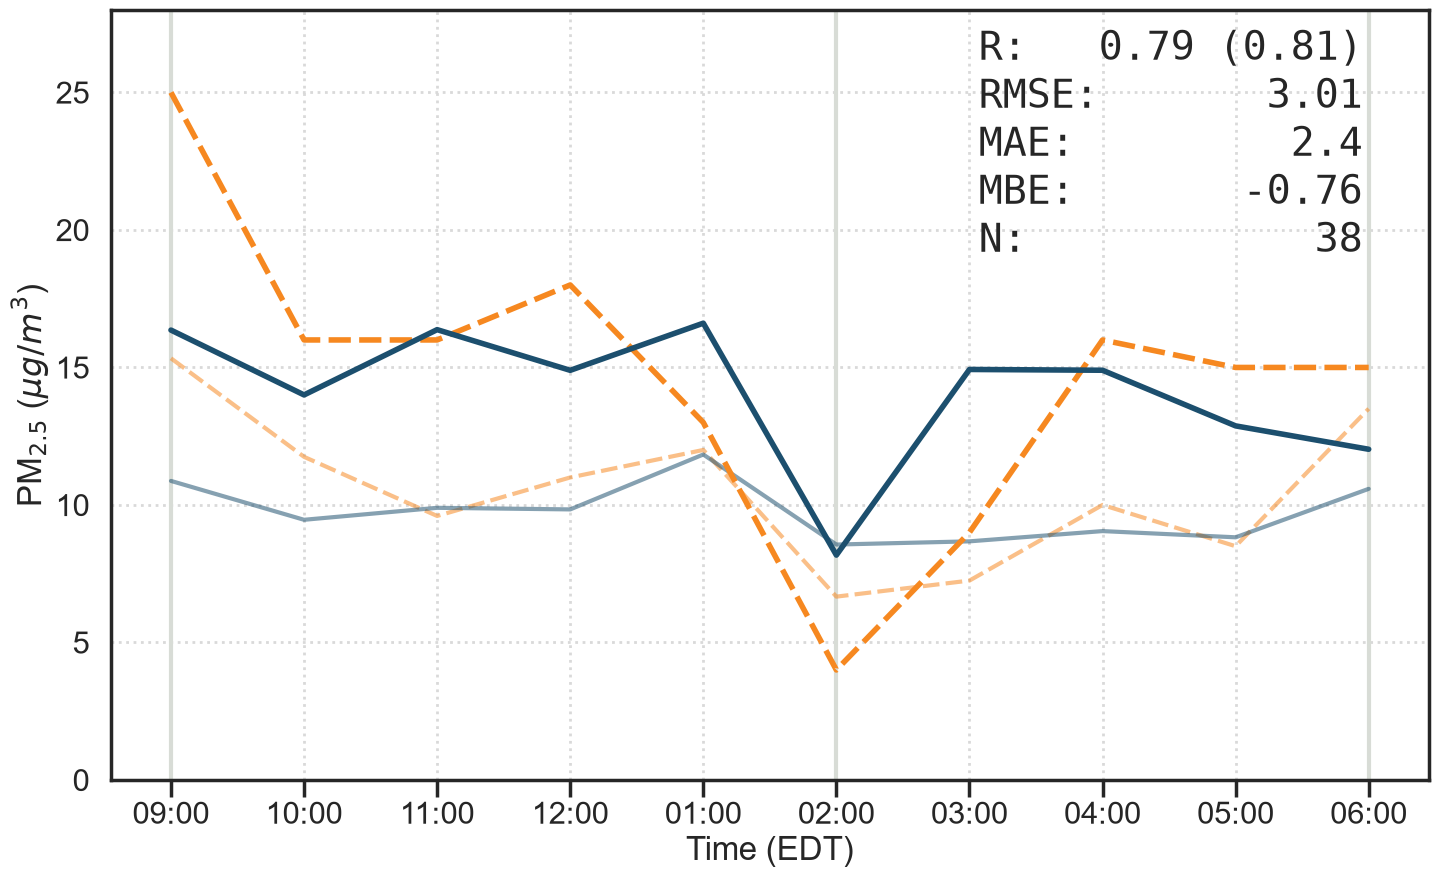

In [ ]:
site = 45
fig,ax = plt.subplots(figsize=(17,10))
rc = {#'axes.labelsize':16,'xtick.labelsize':12,'ytick.labelsize':12,
      'ytick.left':True, 'axes.grid':True, 'grid.color':'.85', 'grid.linestyle':':'}
sns.set_theme(context='poster', style='ticks',rc=rc)
palette = {'tempo_pm': "#1c4f6e", 'epa_pm':"#f68820"}
mean_palette = {'tempo_pm': "#1c4f6e88", 'epa_pm':"#f6882088"}

df = pm_long[pm_long['site']==site].sort_values(by='timestamp')
site_418 = df[df['date'].astype(str) == '2025-04-18'].sort_values(by='timestamp')

sns.lineplot(data=df,x=df['timestamp'].dt.hour,y='pm25',
             hue = 'source',palette = mean_palette, lw=3,
    style='source', style_order=['tempo_pm','epa_pm'],
    estimator='mean',   
    errorbar= None, legend=False       
)
p=sns.lineplot( data = site_418, x = site_418['timestamp'].dt.hour, y = 'pm25',
                  hue = 'source', palette = palette, lw=4,
                  style='source', style_order=['tempo_pm','epa_pm'],
                  errorbar = None, legend = False)
p.set_xticks(ticks=site_418.timestamp.dt.hour.unique())
p.set_xticklabels(labels=site_418.time_naive.unique())#,rotation=30)

p.text(x=0.95, y = 0.98, transform=ax.transAxes,s=
        (
        f"{'R:':3}{spearman_rho_45:6} ({pearson_r_45})\n"
      #   f"{'Spearman:':10}{spearman_rho_45:6}\n"
        f"{'RMSE:':10}{rmse_45:6}\n"
        f"{'MAE:':10}{mae_45:6}\n"
        f"{'MBE:':10}{mbe_45:6}\n"
        f"{'N:':10}{len(pm_45):6}"
        ), ha='right',va='top',size = 'large',font='monospace')
ax.set(xlabel='Time (EDT)',ylabel=r'PM$_{2.5}$ (${\mu}g/m^3$)',ylim=(0,28))
p.vlines(x=[9, 14, 18],
         ymin=0,ymax=28,ls='-',color='xkcd:light grey',zorder=1)
# ax.set_title('Site A',size = 'large', pad = 15)
# fig.savefig(Path.cwd()/f'figs/timeseries_{site}.svg',bbox_inches='tight')
fig.savefig(Path.cwd()/f'figs/timeseries_{site}.png',dpi=200,bbox_inches='tight')

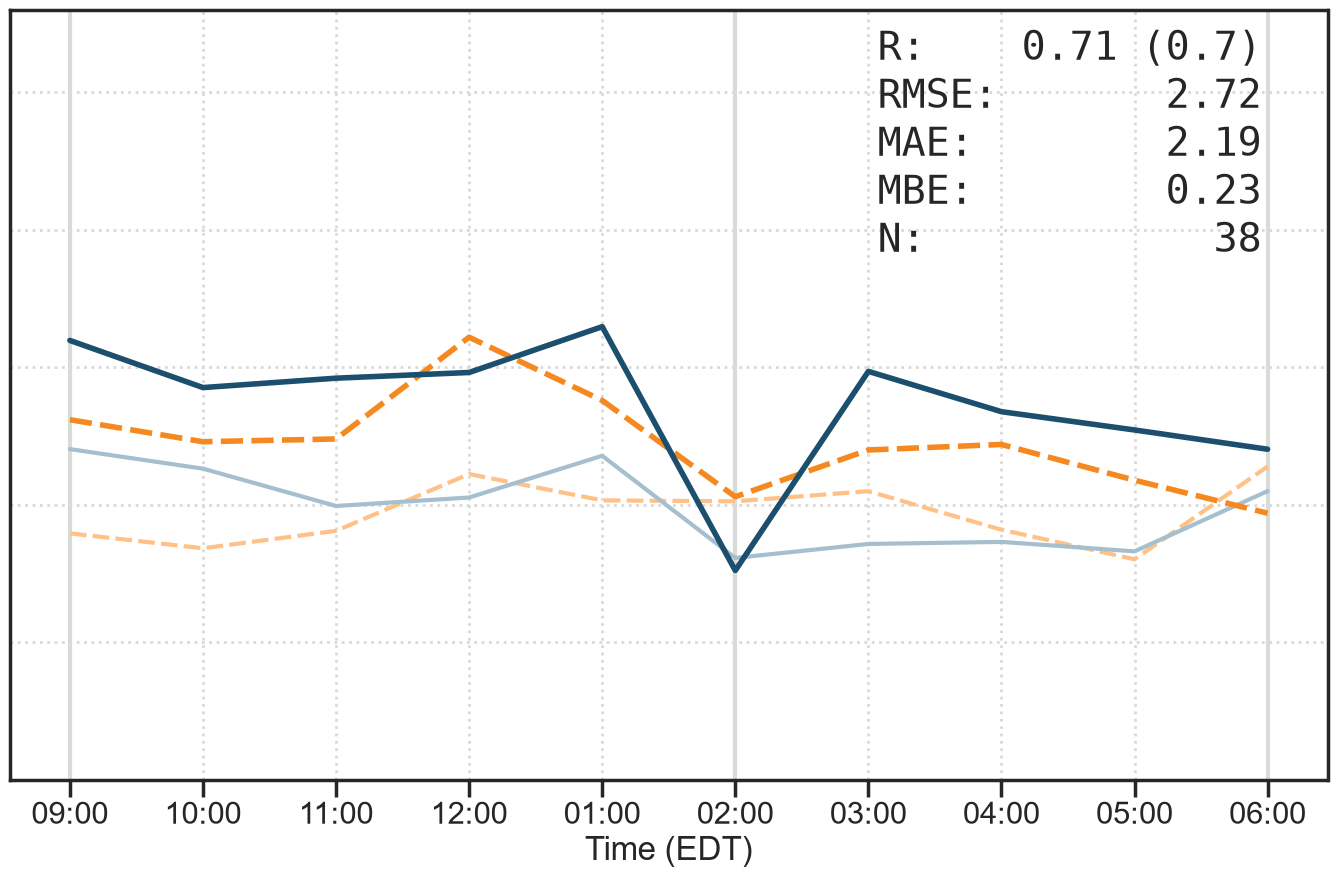

In [103]:
site = 48
fig,ax = plt.subplots(figsize=(17,10))
rc = {#'axes.labelsize':16,'xtick.labelsize':12,'ytick.labelsize':12,
      'ytick.left':False, 'axes.grid':True, 'grid.color':'.85', 'grid.linestyle':':'}
sns.set_theme(context='poster', style='ticks',rc=rc)
palette = {'tempo_pm': "#1c4e6e", 'epa_pm':"#f68820"}
mean_palette = {'tempo_pm': "#a6bfcfff", 'epa_pm':"#ffc187"}

df = pm_long[pm_long['site']==site].sort_values(by='timestamp')
site_418 = df[df['date'].astype(str) == '2025-04-18'].sort_values(by='timestamp')

sns.lineplot(data=df,x=df['timestamp'].dt.hour,y='pm25',
             hue = 'source',palette = mean_palette, lw=3,
    style='source', style_order=['tempo_pm','epa_pm'],
    estimator='mean',   
    errorbar= None, legend=False       
)
p=sns.lineplot( data = site_418, x = site_418['timestamp'].dt.hour, y = 'pm25',
                  hue = 'source', palette = palette, lw=4,
                  style='source', style_order=['tempo_pm','epa_pm'],
                  errorbar = None, legend = False)
p.set_xticks(ticks=site_418.timestamp.dt.hour.unique())
p.set_xticklabels(labels=site_418.time_naive.unique())#,rotation=30)

p.text(x=0.95, y=0.98, transform=ax.transAxes,s=
        (
        f"{'R:':4}{spearman_rho_48:6} ({pearson_r_48})\n"
        #   f"{'Spearman:':10}{spearman_rho_48:6}\n"
        f"{'RMSE:':10}{rmse_48:6}\n"
        f"{'MAE:':10}{mae_48:6}\n"
        f"{'MBE:':10}{mbe_48:6}\n"
        f"{'N:':10}{len(pm_48):6}"
        ), ha='right',va='top',size = 'large',font='monospace')

ax.set(xlabel='Time (EDT)',ylabel='',yticklabels=([]),ylim=(0,28))
p.vlines(x=[9, 14, 18],
         ymin=0,ymax=28,ls='-',color='xkcd:light grey',zorder=1)
# ax.set_title('Site A',size = 'large', pad = 15)
fig.savefig(Path.cwd()/f'figs/timeseries_{site}.svg',bbox_inches='tight')
fig.savefig(Path.cwd()/f'figs/timeseries_{site}.png',dpi=200,bbox_inches='tight')

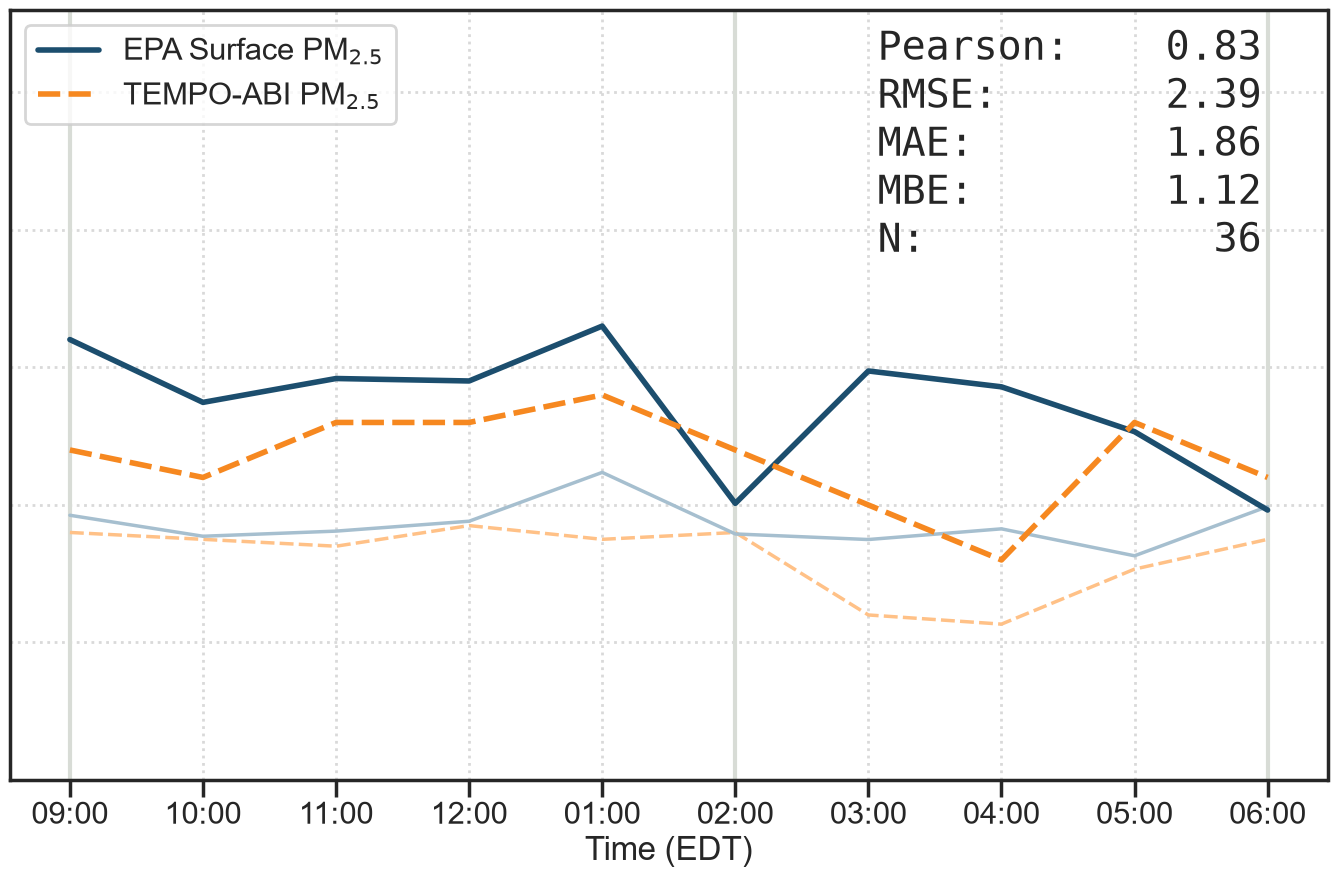

In [104]:
site = 41
fig,ax = plt.subplots(figsize=(17,10))
rc = {#'axes.labelsize':16,'xtick.labelsize':12,'ytick.labelsize':12,
      'ytick.left':False, 'axes.grid':True, 'grid.color':'.85', 'grid.linestyle':':'}
sns.set_theme(context='poster', style='ticks',rc=rc)
palette = {'tempo_pm': "#1c4e6e", 'epa_pm':"#f68820"}
mean_palette = {'tempo_pm': "#a6bfcfff", 'epa_pm':"#ffc187"}

df = pm_long[pm_long['site']==site].sort_values(by='timestamp')
site_418 = df[df['date'].astype(str) == '2025-04-18'].sort_values(by='timestamp')

sns.lineplot(data=df,x=df['timestamp'].dt.hour,y='pm25',
             hue = 'source',palette = mean_palette, lw=2.5,
             style='source', style_order=['tempo_pm','epa_pm'],
             estimator='mean', errorbar= None, legend=False)
p=sns.lineplot( data = site_418, x = site_418['timestamp'].dt.hour, y = 'pm25',
                  hue = 'source', palette = palette, lw=4,
                  style='source', style_order=['tempo_pm','epa_pm'],
                  errorbar = None)
p.set_xticks(ticks=site_418.timestamp.dt.hour.unique())
p.set_xticklabels(labels=site_418.time_naive.unique())#,rotation=30)

p.text(x=0.95, y=0.98, transform=ax.transAxes,s=
        (
        f"{'Pearson:':10}{pearson_r_41:6}\n"
        #   f"{'Spearman:':10}{spearman_rho_41:6}\n"
        f"{'RMSE:':10}{rmse_41:6}\n"
        f"{'MAE:':10}{mae_41:6}\n"
        f"{'MBE:':10}{mbe_41:6}\n"
        f"{'N:':10}{len(pm_41):6}"
        ), ha='right',va='top',size = 'large',font='monospace')

ax.set(xlabel='Time (EDT)',ylabel='',yticklabels=([]),ylim=(0,28))
p.vlines(x=[9, 14, 18],
         ymin=0,ymax=28,ls='-',color='xkcd:light grey',zorder=1)

handles,l = p.get_legend_handles_labels()
by_label = dict(zip(l, handles))
p.legend(handles=by_label.values(),labels = [r'EPA Surface PM$_{2.5}$',r'TEMPO-ABI PM$_{2.5}$'],
         loc='upper left' )
# ax.set_title('Site A',size = 'large', pad = 15)
fig.savefig(Path.cwd()/f'figs/timeseries_{site}.svg',bbox_inches='tight')
fig.savefig(Path.cwd()/f'figs/timeseries_{site}.png',dpi=200,bbox_inches='tight')

In [ ]:
site = 45
fig,ax = plt.subplots(figsize=(16,10))
rc = {#'axes.labelsize':16,'xtick.labelsize':12,'ytick.labelsize':12,
      'ytick.left':True, 'axes.grid':True, 'grid.color':'.85', 'grid.linestyle':':'}
sns.set_theme(context='poster', style='ticks',rc=rc)
palette = {'tempo_pm': "#1c4e6e", 'epa_pm':"#f68820"}
df = pm_long[pm_long['date'].astype(str) == '2025-04-18']
# for site in sitelist:
site_long = df[df['site']==site]#.reset_index(drop=True)
p=sns.lineplot( data = site_long, x = 'timestamp', y = 'pm25',
                  hue = 'source', palette = palette, lw=4,
                  style='source', style_order=['tempo_pm','epa_pm'],
                  errorbar = None, legend = False)
p.set_xticks(ticks=df.timestamp.unique())
p.set_xticklabels(labels=df.time_naive.unique())#,rotation=30)

p.text(x=0.05, y=0.4, transform=ax.transAxes,s=
        (
        f"{'Pearson:':10}{pearson_r_45:6}\n"
        f"{'Spearman:':10}{spearman_rho_45:6}\n"
        f"{'RMSE:':10}{rmse_45:6}\n"
        f"{'MAE:':10}{mae_45:6}\n"
        f"{'MBE:':10}{mbe_45:6}\n"
        f"{'N:':10}{len(pm_45):6}"
        ), ha='left',va='top',size = 'large',font='monospace')
ax.set(xlabel='Time (EDT)',ylabel=r'PM$_{2.5}$ (${\mu}g/m^3$)',ylim=(0,28))
p.vlines(x=['2025-04-18 13:00:00','2025-04-18 18:00:00','2025-04-18 22:00:00'],
         ymin=0,ymax=28,ls='-',color='xkcd:light grey',zorder=1)
# ax.set_title('Site A',size = 'large', pad = 15)
fig.savefig(Path.cwd()/f'figs/timeseries_{site}.svg',bbox_inches='tight')

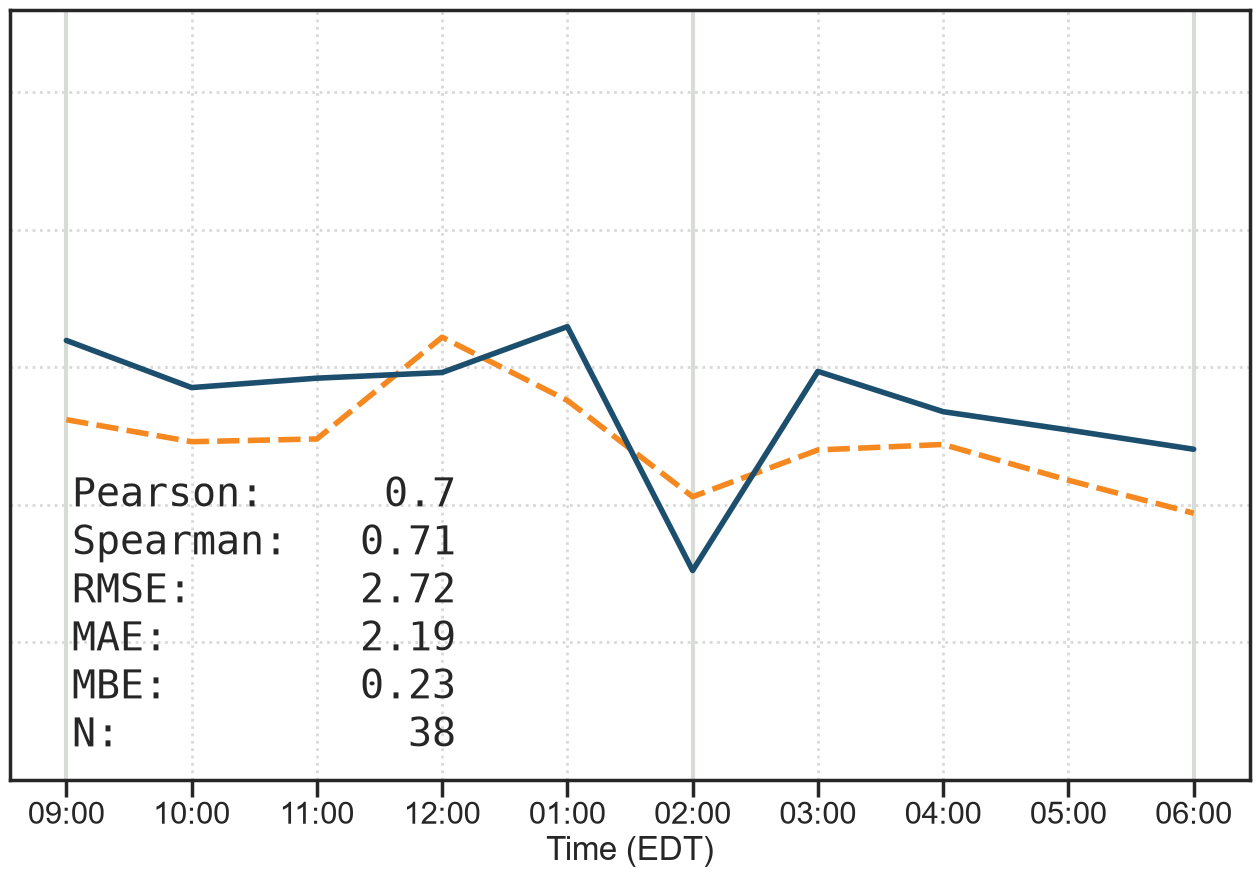

In [65]:
site = 48
fig,ax = plt.subplots(figsize=(16,10))
rc = {'axes.grid':True, 'grid.color':'.85', 'grid.linestyle':':', 'ytick.left': False}
sns.set_theme(context='poster', style='ticks',rc=rc)
palette = {'tempo_pm': "#1c4e6e", 'epa_pm':"#f68820"}
df = pm_long[pm_long['date'].astype(str) == '2025-04-18']
# for site in sitelist:
site_long = df[df['site']==site]

p=sns.lineplot( data = site_long, x = 'timestamp', y = 'pm25',
                  hue = 'source', palette = palette, lw=4,
                  style='source', style_order=['tempo_pm','epa_pm'],
                  errorbar = None, legend = False)
p.text(x=0.05, y=0.4, transform=ax.transAxes,s=
        (
        f"{'Pearson:':10}{pearson_r_48:6}\n"
        f"{'Spearman:':10}{spearman_rho_48:6}\n"
        f"{'RMSE:':10}{rmse_48:6}\n"
        f"{'MAE:':10}{mae_48:6}\n"
        f"{'MBE:':10}{mbe_48:6}\n"
        f"{'N:':10}{len(pm_48):6}"
        ), ha='left',va='top',size = 'large',font='monospace')
p.vlines(x=['2025-04-18 13:00:00','2025-04-18 18:00:00','2025-04-18 22:00:00'],
         ymin=0,ymax=28,ls='-',color='xkcd:light grey',zorder=1)

p.set_xticks(ticks=df.timestamp.unique())
p.set_xticklabels(labels=df.time_naive.unique())
ax.set(xlabel='Time (EDT)',ylabel='',yticklabels=([]),ylim=(0,28))

fig.savefig(Path.cwd()/f'figs/timeseries_{site}.svg',bbox_inches='tight')


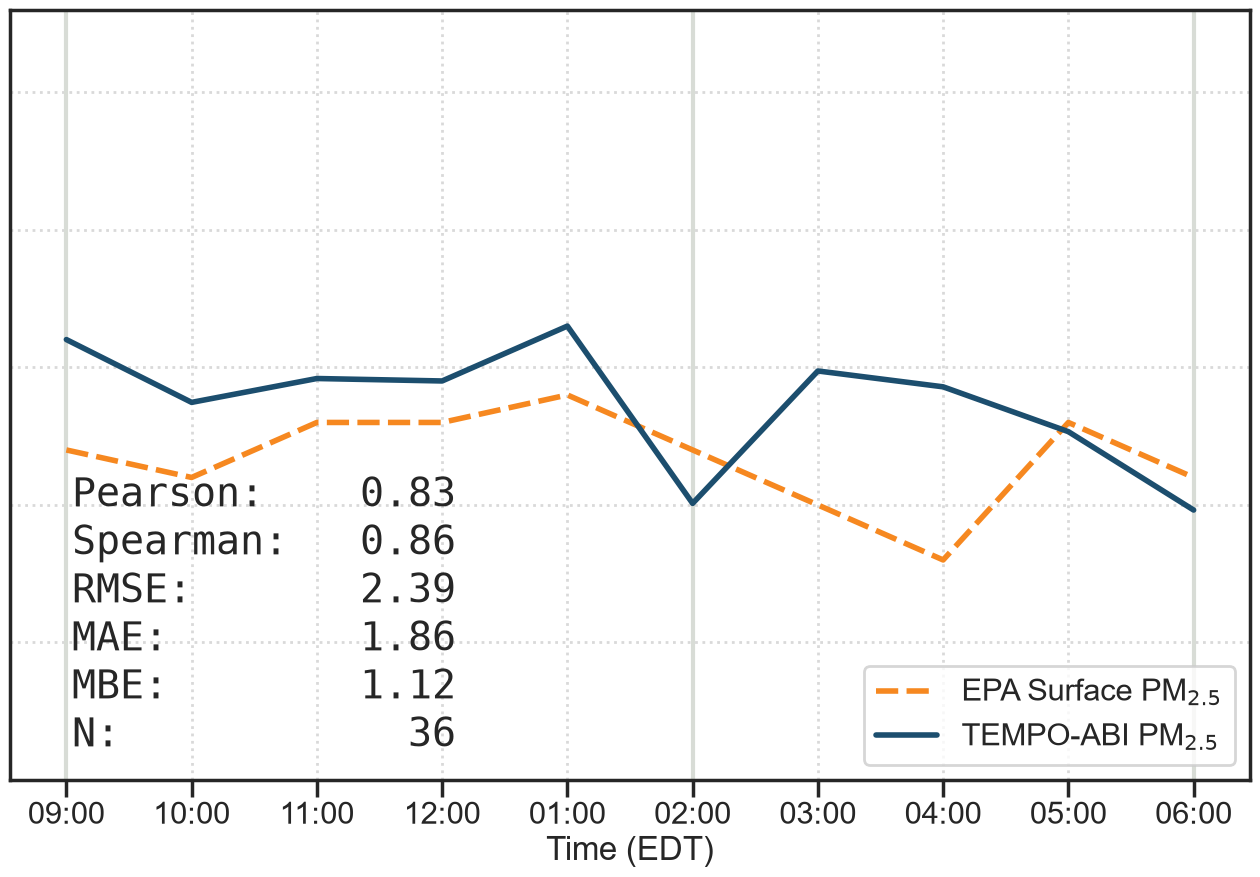

In [ ]:
site = 41
fig,ax = plt.subplots(figsize=(16,10))
rc = {'axes.grid':True, 'grid.color':'.85', 'grid.linestyle':':', 'ytick.left': False, 'ytick.right':False}
sns.set_theme(context='poster', style='ticks',rc=rc)
palette = {'tempo_pm': "#1c4e6e", 'epa_pm':"#f68820"}
df = pm_long[pm_long['date'].astype(str) == '2025-04-18']
# for site in sitelist:
site_long = df[df['site']==site]#.reset_index(drop=True)

p=sns.lineplot( data = site_long, x = 'timestamp', y = 'pm25',
                  hue = 'source', palette = palette, lw=4,
                  style='source', style_order=['tempo_pm','epa_pm'],
                  errorbar = None)

p.text(x=0.05, y=0.4, transform=ax.transAxes,s=
        (
        f"{'Pearson:':10}{pearson_r_41:6}\n"
        f"{'Spearman:':10}{spearman_rho_41:6}\n"
        f"{'RMSE:':10}{rmse_41:6}\n"
        f"{'MAE:':10}{mae_41:6}\n"
        f"{'MBE:':10}{mbe_41:6}\n"
        f"{'N:':10}{len(pm_41):6}"
        ), ha='left',va='top',size = 'large',font='monospace')

p.set_xticks(ticks=df.timestamp.unique())
p.set_xticklabels(labels=df.time_naive.unique())
ax.set(xlabel='Time (EDT)',ylabel='',yticklabels=([]),ylim=(0,28))
p.vlines(x=['2025-04-18 13:00:00','2025-04-18 18:00:00','2025-04-18 22:00:00'],
         ymin=0,ymax=28,ls='-',color='xkcd:light grey',zorder=1)
handles,l = p.get_legend_handles_labels()
by_label = dict(zip(l, handles))
p.legend(handles=by_label.values(),labels = [r'EPA Surface PM$_{2.5}$',r'TEMPO-ABI PM$_{2.5}$'],
         loc='lower right')
fig.savefig(Path.cwd()/f'figs/timeseries_{site}.svg',bbox_inches='tight')
fig.savefig(Path.cwd()/f'figs/timeseries_{site}.svg',bbox_inches='tight')